# Week 1: Pair Programming Exercise - "Regression Relay"

**Dataset:** Diabetes Dataset (sklearn built-in)  
**Time:** 30 minutes  
**Mode:** Pair Programming (Navigator + Driver)

---

## 🎯 Learning Objectives

By completing this exercise, you will:
- Apply the complete ML pipeline independently
- Practice the sklearn API pattern without instructor guidance
- Collaborate with a peer using industry pair programming practices
- Troubleshoot errors together
- Interpret coefficients to identify important features

---

## 👥 How Pair Programming Works

**Two roles:**

1. **NAVIGATOR** 🧭
   - Describes what to do ("Now we need to import train_test_split")
   - Thinks strategically about the overall approach
   - Does NOT type code
   - Catches errors and suggests fixes

2. **DRIVER** ⌨️
   - Types what the navigator describes
   - Asks clarifying questions
   - Does NOT make independent decisions
   - Focuses on syntax and implementation

**IMPORTANT:** Switch roles every 10 minutes (instructor will announce)

---

## 📋 Your Task

Build a complete linear regression pipeline on the **Diabetes dataset** to predict disease progression.

**Steps to complete:**

1. ✅ Load the Diabetes dataset from `sklearn.datasets`
2. ✅ Explore data shapes and feature names
3. ✅ Split data properly (80/20, random_state=42)
4. ✅ Train a Linear Regression model
5. ✅ Make predictions on test set
6. ✅ Calculate R², MSE, and RMSE
7. ✅ Create a residual plot
8. ✅ **Bonus:** Identify the 3 most important features by coefficient magnitude

---

## 🚀 Getting Started

**Before you begin:**
- Decide who starts as Navigator and who starts as Driver
- Remember: Navigator describes, Driver types
- Don't be afraid to make mistakes - that's how you learn!
- If stuck, check the hints at the bottom of this notebook

**Let's begin!**

---

## Task 1: Setup & Imports

**What you need:**
- `load_diabetes` from sklearn.datasets (note: different from California Housing!)
- `train_test_split` from sklearn.model_selection
- `LinearRegression` from sklearn.linear_model
- `mean_squared_error, r2_score` from sklearn.metrics
- `matplotlib.pyplot` as plt
- `numpy` as np

In [1]:
# All imports are PROVIDED - focus on understanding, not memorizing syntax
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

print("✅ Imports complete!")

✅ Imports complete!


---

## Task 2: Load & Explore Data

**Instructions:**
1. Load the diabetes dataset using `load_diabetes()`
2. Extract X (features) and y (target)
3. Print:
   - Shape of X
   - Shape of y
   - Feature names
   - Description of what the target represents

**Hint:** The function is `load_diabetes()`, not `fetch_diabetes()`

In [3]:
# TODO: Load and extract the diabetes dataset
data = load_diabetes()
X = data.data        # Extract the features
y = data.target        # Extract the target values

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
print(f"Feature names: {data.feature_names}")
print(f"\nTarget description: {data.DESCR.split('Target')}")

Shape of X: (442, 10)
Shape of y: (442,)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target description: ['.. _diabetes_dataset:\n\nDiabetes dataset\n----------------\n\nTen baseline variables, age, sex, body mass index, average blood\npressure, and six blood serum measurements were obtained for each of n =\n442 diabetes patients, as well as the response of interest, a\nquantitative measure of disease progression one year after baseline.\n\n**Data Set Characteristics:**\n\n:Number of Instances: 442\n\n:Number of Attributes: First 10 columns are numeric predictive values\n\n:', ': Column 11 is a quantitative measure of disease progression one year after baseline\n\n:Attribute Information:\n    - age     age in years\n    - sex\n    - bmi     body mass index\n    - bp      average blood pressure\n    - s1      tc, total serum cholesterol\n    - s2      ldl, low-density lipoproteins\n    - s3      hdl, high-density lipoproteins\n    - s4      tch, total

**Questions to discuss with your partner:**
- How many patients are in the dataset?
- How many features does each patient have?
- What are the feature names? Do they make sense medically?

---

## Task 3: Split Data

**⚠️ CRITICAL!**

**Instructions:**
1. Split into training and test sets
2. Use test_size=0.2 (80/20 split)
3. Use random_state=42 for reproducibility
4. Print the shapes of all four resulting arrays

**Navigator:** Remind the driver about the importance of this step!

In [5]:
# TODO: Split the data into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # Proportion for test set
    random_state=13    # Ensures reproducible splits
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (353, 10)
Test set: (89, 10)


**Checkpoint:** Does your training set have about 353 samples and test set about 89 samples?

---

## ⏱️ 10-MINUTE MARK: SWITCH ROLES!

If you were Navigator, you're now Driver.  
If you were Driver, you're now Navigator.

---

## Task 4: Train Model

**Instructions:**
1. Create a LinearRegression model
2. Fit it to the training data
3. Display all coefficients with their feature names
4. Display the intercept

**Remember:** Create → Fit → (Predict comes next)

In [6]:
# TODO: Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)  # Which method trains the model?

print("✅ Model trained!")
print("\nModel coefficients:")
for feature, coef in zip(data.feature_names, model.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"\nIntercept: {model.intercept_:.4f}")

✅ Model trained!

Model coefficients:
  age: -17.2869
  sex: -248.0886
  bmi: 578.2795
  bp: 315.7300
  s1: -571.3257
  s2: 292.4307
  s3: -17.4649
  s4: 120.1834
  s5: 695.0142
  s6: 108.0530

Intercept: 150.2337


**Discuss with your partner:**
- Which features have the largest absolute coefficients?
- What does a positive vs negative coefficient mean for disease progression?

---

## Task 5: Make Predictions

**Instructions:**
1. Use the trained model to predict on X_test
2. Display first 10 predictions vs actual values
3. Show the difference (residual) for each

In [10]:
# TODO: Generate predictions on the test set
y_pred = model.predict(X_test)  # Which method makes predictions?
print("First 10 predictions vs actual:")
for i in range(10):
    residual = y_test.iloc[i] - y_pred[i] if hasattr(y_test, 'iloc') else y_test[i] - y_pred[i]
    actual = y_test.iloc[i] if hasattr(y_test, 'iloc') else y_test[i]
    print(f"Predicted: {y_pred[i]:6.2f}, Actual: {actual:6.2f}, Residual: {residual:6.2f}")

First 10 predictions vs actual:
Predicted: 244.74, Actual: 272.00, Residual:  27.26
Predicted:  45.58, Actual:  90.00, Residual:  44.42
Predicted: 152.61, Actual:  86.00, Residual: -66.61
Predicted: 189.14, Actual: 232.00, Residual:  42.86
Predicted: 287.96, Actual: 281.00, Residual:  -6.96
Predicted: 141.66, Actual:  88.00, Residual: -53.66
Predicted: 169.13, Actual: 235.00, Residual:  65.87
Predicted: 207.04, Actual: 151.00, Residual: -56.04
Predicted: 227.49, Actual: 152.00, Residual: -75.49
Predicted:  78.37, Actual:  98.00, Residual:  19.63


---

## Task 6: Evaluate Model

**Instructions:**
1. Calculate Mean Squared Error (MSE)
2. Calculate Root Mean Squared Error (RMSE)
3. Calculate R² score
4. Display all three metrics with clear labels
5. Interpret: Is this a good model?

In [11]:
# TODO: Calculate model performance metrics
mse = mean_squared_error(y_test, y_pred)  # Compare actual vs predicted
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)             # Same comparison

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"\nInterpretation: The model explains {r2*100:.1f}% of variance in disease progression.")

Mean Squared Error (MSE): 3104.2064
Root Mean Squared Error (RMSE): 55.7154
R² Score: 0.3670

Interpretation: The model explains 36.7% of variance in disease progression.


**Interpretation space:**

My R² score is: ___________

This means my model explains ___________% of variance in disease progression.

I think this is a good/okay/poor model because: ___________

---

## ⏱️ 20-MINUTE MARK: SWITCH ROLES AGAIN!

Final role switch - keep going!

---

## Task 7: Residual Plot

**Instructions:**
1. Calculate residuals (y_test - y_pred)
2. Create a scatter plot of predicted values (x-axis) vs residuals (y-axis)
3. Add a horizontal red line at y=0
4. Label axes clearly
5. Add a title

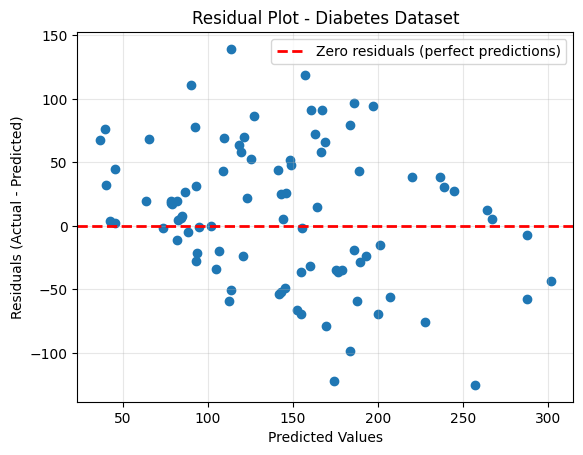

In [12]:
# TODO: Create a residual plot to check model assumptions
residuals = y_test - y_pred  # Calculate residuals (actual minus predicted)

# TODO: Create scatter plot - what goes on each axis?
plt.scatter(y_pred, residuals)  # x-axis? y-axis?

# Plot decoration is PROVIDED - focus on understanding what you're plotting
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero residuals (perfect predictions)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot - Diabetes Dataset')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# TODO: Analyze the plot - do you see random scatter or a pattern?

**Analyze your residual plot:**

1. Is there random scatter around zero, or do you see a pattern?
2. Is there a funnel shape (increasing variance)?
3. Is there a curve (non-linear relationship)?
4. Based on this, is linear regression appropriate for this data?

**Your analysis:**

(Write your observations here)

---

## 🌟 BONUS TASK: Feature Importance

**Challenge:** Identify the 3 most important features

**Hint:** Look at the absolute value of coefficients. Larger magnitude = more influence on predictions.

**Instructions:**
1. Create a list of (feature_name, coefficient) tuples
2. Sort by absolute value of coefficient
3. Display top 3

In [13]:
# BONUS: Identify top 3 most important features
# Hint: Larger absolute coefficient = more influence on predictions

feature_importance = list(zip(data.feature_names, np.abs(model.coef_)))  # Get absolute coefficients
feature_importance_sorted = sorted(feature_importance, key=lambda x: x[1], reverse=True)  # Sort by coefficient

print("Top 3 most important features:")
for i in range(3):
    feature_name, coef_value = feature_importance_sorted[i]
    print(f"{i+1}. {feature_name}: {coef_value:.4f}")

Top 3 most important features:
1. s5: 695.0142
2. bmi: 578.2795
3. s1: 571.3257


**Medical interpretation:**

The top 3 features affecting disease progression are:

1. ___________
2. ___________
3. ___________

This makes sense because: ___________

---

## 🎉 Congratulations!

You've completed the pair programming exercise!

**What you accomplished:**
- ✅ Built a complete ML pipeline from scratch
- ✅ Worked collaboratively using industry practices
- ✅ Applied concepts without instructor step-by-step guidance
- ✅ Interpreted model results
- ✅ Validated model assumptions with residual plot

---

## 💬 Reflection

**Discuss with your partner:**

1. What was the most challenging part?
2. What did you learn from working together?
3. How did pair programming help (or hinder) your learning?
4. What would you do differently next time?

---

## 📊 Compare Your Results

**Typical results for this dataset:**
- R² ≈ 0.45-0.55 (explaining ~50% of variance)
- RMSE ≈ 53-58 (in diabetes progression units)
- Top features usually include: bmi, bp, s5 (blood serum measurement)

**How did you do?**

---

## 🚀 Next Steps

1. **Tonight:** Complete the post-class exercise (Diabetes dataset, individual work)
2. **Tomorrow:** Solution notebook will be posted - compare your approach
3. **Next week:** Classification! We'll see how linear regression transforms into logistic regression

---

## 📚 Additional Resources (Optional)

Want to learn more?
- [sklearn Diabetes Dataset Documentation](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset)
- [Understanding Residual Plots](https://www.statology.org/residual-plot/)
- [Feature Importance in Linear Models](https://towardsdatascience.com/feature-importance-in-linear-models-8f47c391d32c)

---

---

# 💡 HINTS (Only look if stuck!)

<details>
<summary><b>Hint 1: Loading Data</b> (Click to expand)</summary>

```python
from sklearn.datasets import load_diabetes
data = load_diabetes()
X = data.data
y = data.target
```
</details>

<details>
<summary><b>Hint 2: Splitting Data</b></summary>

```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
```
</details>

<details>
<summary><b>Hint 3: Training Model</b></summary>

```python
model = LinearRegression()
model.fit(X_train, y_train)
```
</details>

<details>
<summary><b>Hint 4: Evaluation Metrics</b></summary>

```python
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
```
</details>

<details>
<summary><b>Hint 5: Residual Plot</b></summary>

```python
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()
```
</details>

<details>
<summary><b>Bonus Hint: Feature Importance</b></summary>

```python
feature_importance = list(zip(data.feature_names, np.abs(model.coef_)))
feature_importance_sorted = sorted(feature_importance, key=lambda x: x[1], reverse=True)
print("Top 3 features:")
for i in range(3):
    print(f"{i+1}. {feature_importance_sorted[i][0]}: {feature_importance_sorted[i][1]:.4f}")
```
</details>